# PBMF — knowledge distillation to a decision tree (step 5)

The ensemble's pruned consensus score is a black-box vector. For clinical adoption we want a human-readable rule. Fit a shallow decision tree to reproduce the ensemble's high-confidence B+/B- calls from the raw features.

**Design:**
1. Train the same ensemble as `pbmf_ensemble.ipynb` on POPLAR (M=1000, seed=0, λ_control=0).
2. Prune at the 95th percentile → mean of kept models = consensus score on POPLAR.
3. Filter to *high-confidence* patients: keep only those with |score - 0.5| > ε (ε = 0.1 → drop the 0.4–0.6 ambiguous band).
4. Fit `DecisionTreeClassifier(max_depth=4)` on the filtered (X, y = score > 0.5).
5. Apply tree to OAK → `evaluate_biomarker`. Compare HR+/HR- ensemble vs tree.

The tree is expected to *underperform* the ensemble — maybe HR+/HR- slides from ~0.58 up toward ~0.7 — but in exchange we get a readable rule.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from pbmf import (
    build_features, evaluate_biomarker, plot_km_strata,
    train_pbmf_ensemble, score_ensemble, prune_ensemble, distill_tree,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3g}")

feat, genes = build_features()
feat = feat.dropna(subset=["OS", "OS_event", "blSLD"]).reset_index(drop=True)

clinical_cols = ["age", "sex_M", "ecog", "blSLD", "metsites",
                 "hist_squamous", "ever_smoker", "msaf", "btmb"]
mut_cols = [c for c in feat.columns if c.startswith("mut_")]
feature_names = clinical_cols + mut_cols

poplar_mask = feat["Trial"].values == "POPLAR"
oak_mask    = feat["Trial"].values == "OAK"

# Scaler only fits on POPLAR (no held-out leakage). Raw features (X_raw)
# are kept on the original scale for tree interpretability — trees don't
# need scaled inputs, and raw bTMB thresholds read like clinical cutoffs.
scaler = StandardScaler().fit(feat.loc[poplar_mask, clinical_cols])
X_scaled = np.hstack([
    scaler.transform(feat[clinical_cols]),
    feat[mut_cols].values,
]).astype(np.float32)
X_raw = np.hstack([
    feat[clinical_cols].values,
    feat[mut_cols].values,
]).astype(np.float32)
times  = feat["OS"].values.astype(np.float32)
events = feat["OS_event"].values.astype(np.int64)
arm    = (feat["TRT01P"] == "Atezolizumab").astype(int).values

print(f"POPLAR train: {poplar_mask.sum()}  OAK held: {oak_mask.sum()}")
print(f"Features: {len(feature_names)}")

/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jaschabeste/repositories/pbmf-reproduction/pbmf/data.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.read_excel(xlsx_path, sheet_name=sheet).replace({".": np.nan})


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jaschabeste/repositories/pbmf-reproduction/pbmf/data.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.read_excel(xlsx_path, sheet_name=sheet).replace({".": np.nan})


POPLAR train: 211  OAK held: 641
Features: 29


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


## Train ensemble and compute consensus scores on POPLAR

Same hyperparameters as `pbmf_ensemble.ipynb`. ~10 min.

In [2]:
t0 = time.time()
ensemble = train_pbmf_ensemble(
    X_scaled[poplar_mask], times[poplar_mask], events[poplar_mask], arm[poplar_mask],
    M=1000, steps=500, lr=1e-2, patient_bag=0.8,
    n_features=X_scaled.shape[1] - 1, ifrac=0.1, lam_control=0.0,
    seed=0, verbose=250,
)
print(f"trained {len(ensemble)} models in {time.time() - t0:.1f}s")

poplar_scores_all = score_ensemble(ensemble, X_scaled[poplar_mask])
oak_scores_all    = score_ensemble(ensemble, X_scaled[oak_mask])
kept, diag = prune_ensemble(poplar_scores_all, percentile=95)
print(f"kept {len(kept)}/{len(ensemble)} after pruning")

poplar_consensus = poplar_scores_all[:, kept].mean(axis=1)
oak_consensus    = oak_scores_all[:, kept].mean(axis=1)

  trained 250/1000  (0 sign-flipped)


  trained 500/1000  (0 sign-flipped)


  trained 750/1000  (0 sign-flipped)


  trained 1000/1000  (0 sign-flipped)
trained 1000 models in 526.9s


kept 48/1000 after pruning


In [3]:
# Anchor: what does the ensemble itself score on OAK?
oak_df_ens = feat[oak_mask].assign(score=oak_consensus,
                                   bplus=(oak_consensus >= 0.5).astype(int))
ens_row = evaluate_biomarker(oak_df_ens, label_col="bplus").as_series()
ens_row["B+ rate"] = f"{oak_df_ens['bplus'].mean():.1%}"
print("Ensemble (post-prune) on OAK:")
print(ens_row.to_string())

Ensemble (post-prune) on OAK:
n_B+                       475
n_B-                       166
HR(Tx|B+)                0.585
CI(Tx|B+)         [0.47, 0.73]
p(Tx|B+)              1.69e-06
HR(Tx|B-)                 1.01
CI(Tx|B-)         [0.72, 1.41]
p(Tx|B-)                 0.955
HR+/HR-                   0.58
p(interaction)          0.0103
B+ rate                  74.1%


## Distill: tree on 29 features, max_depth=4, ε=0.1

Use raw-scale features so the tree's thresholds read in clinical units.

In [4]:
X_poplar_raw = X_raw[poplar_mask]
X_oak_raw    = X_raw[oak_mask]

tree, conf_mask, summary = distill_tree(
    scores=poplar_consensus,
    X=X_poplar_raw,
    feature_names=feature_names,
    max_depth=4, epsilon=0.1, min_samples_leaf=10,
    ccp_alpha=0.005, random_state=0,
)
print("Distillation summary:", summary)

Distillation summary: {'n_total': 211, 'n_confident': 202, 'n_ambiguous': 9, 'n_bplus_in_train': 138, 'train_accuracy': 0.8415841584158416, 'epsilon': 0.1, 'max_depth': 4, 'ccp_alpha': 0.005}


|--- msaf <= 0.11
|   |--- blSLD <= 141.50
|   |   |--- blSLD <= 81.50
|   |   |   |--- age <= 72.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  72.50
|   |   |   |   |--- class: 1
|   |   |--- blSLD >  81.50
|   |   |   |--- msaf <= 0.04
|   |   |   |   |--- class: 1
|   |   |   |--- msaf >  0.04
|   |   |   |   |--- class: 1
|   |--- blSLD >  141.50
|   |   |--- class: 0
|--- msaf >  0.11
|   |--- mut_LRP1B <= 0.50
|   |   |--- class: 0
|   |--- mut_LRP1B >  0.50
|   |   |--- age <= 57.50
|   |   |   |--- class: 1
|   |   |--- age >  57.50
|   |   |   |--- class: 0



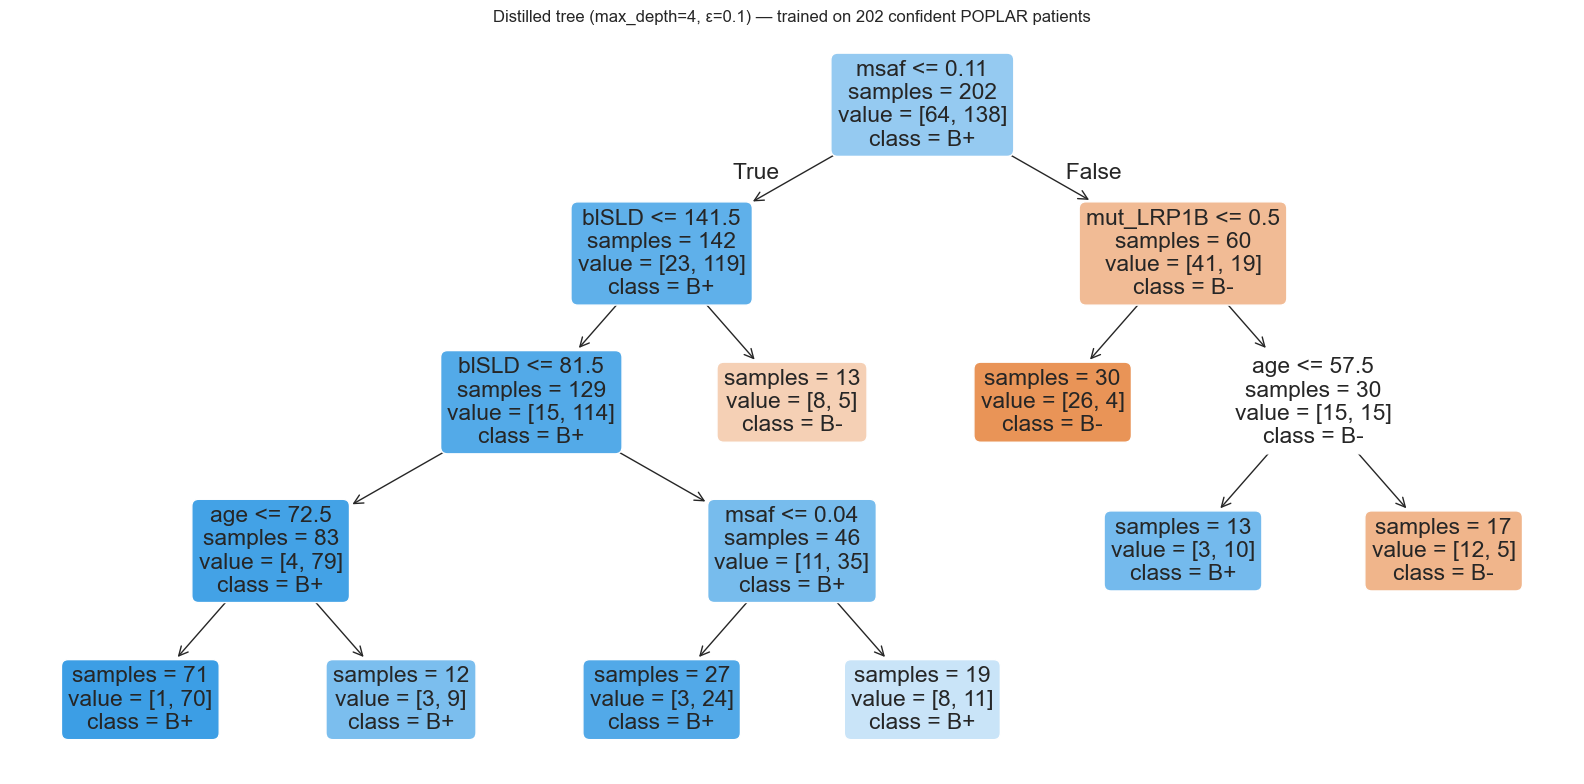

In [5]:
# Render the tree
print(export_text(tree, feature_names=feature_names))

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree, feature_names=feature_names, class_names=["B-", "B+"],
          filled=True, rounded=True, precision=2, impurity=False, ax=ax)
ax.set_title(f"Distilled tree (max_depth=4, ε=0.1) — trained on {summary['n_confident']} confident POPLAR patients")
plt.tight_layout()

In [6]:
# Apply tree to OAK and compare
oak_tree_pred = tree.predict(X_oak_raw)
oak_df_tree = feat[oak_mask].assign(bplus=oak_tree_pred.astype(int))
tree_row = evaluate_biomarker(oak_df_tree, label_col="bplus").as_series()
tree_row["B+ rate"] = f"{oak_df_tree['bplus'].mean():.1%}"

# Agreement between tree and ensemble on OAK
ens_label_oak = (oak_consensus >= 0.5).astype(int)
agree = (oak_tree_pred == ens_label_oak).mean()

# bTMB baseline
btmb_df = feat[oak_mask].assign(bplus=(feat.loc[oak_mask, "btmb"] >= 16).astype(int))
btmb_row = evaluate_biomarker(btmb_df, label_col="bplus").as_series()
btmb_row["B+ rate"] = f"{btmb_df['bplus'].mean():.1%}"

summary_table = pd.DataFrame({
    "Ensemble (post-prune)": ens_row,
    "Distilled tree (29 feat, d=4)": tree_row,
    "bTMB ≥ 16 baseline": btmb_row,
})
print(f"Tree-vs-ensemble agreement on OAK: {agree:.1%}\n")
summary_table

Tree-vs-ensemble agreement on OAK: 82.8%



,Ensemble (post-prune),"Distilled tree (29 feat, d=4)",bTMB ≥ 16 baseline
n_B+,475,459,160
n_B-,166,182,481
HR(Tx|B+),0.585,0.578,0.622
CI(Tx|B+),"[0.47, 0.73]","[0.46, 0.72]","[0.43, 0.90]"
p(Tx|B+),1.69e-06,1.65e-06,0.0121
HR(Tx|B-),1.01,0.943,0.684
CI(Tx|B-),"[0.72, 1.41]","[0.68, 1.30]","[0.55, 0.85]"
p(Tx|B-),0.955,0.719,0.000442
HR+/HR-,0.58,0.614,0.91
p(interaction),0.0103,0.0215,0.48


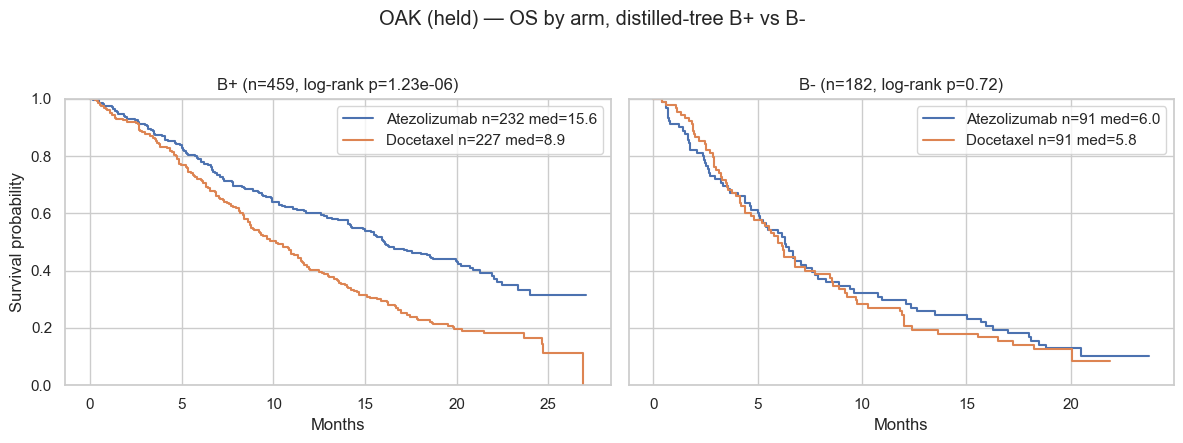

In [7]:
plot_km_strata(oak_df_tree, label_col="bplus",
               title="OAK (held) — OS by arm, distilled-tree B+ vs B-")
plt.show()

## Tree on 9 clinical features only — maximum interpretability

In [8]:
clin_idx = list(range(len(clinical_cols)))
X_poplar_clin = X_poplar_raw[:, clin_idx]
X_oak_clin    = X_oak_raw[:, clin_idx]

tree_clin, _, summary_clin = distill_tree(
    scores=poplar_consensus, X=X_poplar_clin,
    feature_names=clinical_cols,
    max_depth=4, epsilon=0.1, min_samples_leaf=10,
    ccp_alpha=0.005, random_state=0,
)
print("Clinical-only tree:", summary_clin)
print(export_text(tree_clin, feature_names=clinical_cols))

oak_df_clin = feat[oak_mask].assign(bplus=tree_clin.predict(X_oak_clin).astype(int))
clin_row = evaluate_biomarker(oak_df_clin, label_col="bplus").as_series()
clin_row["B+ rate"] = f"{oak_df_clin['bplus'].mean():.1%}"
print()
print("Clinical-only tree on OAK:")
print(clin_row.to_string())

Clinical-only tree: {'n_total': 211, 'n_confident': 202, 'n_ambiguous': 9, 'n_bplus_in_train': 138, 'train_accuracy': 0.8267326732673267, 'epsilon': 0.1, 'max_depth': 4, 'ccp_alpha': 0.005}
|--- msaf <= 0.11
|   |--- blSLD <= 141.50
|   |   |--- blSLD <= 81.50
|   |   |   |--- age <= 72.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  72.50
|   |   |   |   |--- class: 1
|   |   |--- blSLD >  81.50
|   |   |   |--- msaf <= 0.04
|   |   |   |   |--- class: 1
|   |   |   |--- msaf >  0.04
|   |   |   |   |--- class: 1
|   |--- blSLD >  141.50
|   |   |--- class: 0
|--- msaf >  0.11
|   |--- age <= 52.50
|   |   |--- class: 1
|   |--- age >  52.50
|   |   |--- hist_squamous <= 0.50
|   |   |   |--- class: 0
|   |   |--- hist_squamous >  0.50
|   |   |   |--- class: 0


Clinical-only tree on OAK:
n_B+                       456
n_B-                       185
HR(Tx|B+)                  0.6
CI(Tx|B+)         [0.48, 0.75]
p(Tx|B+)              8.69e-06
HR(Tx|B-)                0.843
CI(

## Depth sweep — interpretability vs fidelity

Shallow trees are easier to read but reproduce the ensemble less faithfully. Sweep depth from 2 to 6 on the full 29-feature tree.

In [9]:
rows = []
for d in [2, 3, 4, 5, 6]:
    t, _, s = distill_tree(
        scores=poplar_consensus, X=X_poplar_raw, feature_names=feature_names,
        max_depth=d, epsilon=0.1, min_samples_leaf=10, random_state=0,
    )
    pred_oak = t.predict(X_oak_raw)
    agr = (pred_oak == ens_label_oak).mean()
    df = feat[oak_mask].assign(bplus=pred_oak.astype(int))
    r = evaluate_biomarker(df, label_col="bplus").as_series()
    rows.append({
        "depth": d,
        "n_leaves": t.get_n_leaves(),
        "train_acc": s["train_accuracy"],
        "OAK agree w/ ensemble": agr,
        "OAK B+ rate": df["bplus"].mean(),
        "OAK HR(Tx|B+)": r["HR(Tx|B+)"],
        "OAK HR(Tx|B-)": r["HR(Tx|B-)"],
        "OAK HR+/HR-":   r["HR+/HR-"],
        "OAK int p":     r["p(interaction)"],
    })
depth_sweep = pd.DataFrame(rows).set_index("depth")
depth_sweep.round(3)

,n_leaves,train_acc,OAK agree w/ ensemble,OAK B+ rate,OAK HR(Tx|B+),OAK HR(Tx|B-),OAK HR+/HR-,OAK int p
depth,,,,,,,,
2,4,0.807,0.814,0.683,0.58,0.92,0.631,0.023
3,7,0.842,0.828,0.716,0.578,0.943,0.614,0.022
4,9,0.842,0.828,0.716,0.578,0.943,0.614,0.022
5,11,0.842,0.828,0.716,0.578,0.943,0.614,0.022
6,12,0.842,0.828,0.716,0.578,0.943,0.614,0.022


## ε sweep — how aggressively to filter ambiguous patients

Higher ε = train only on the ensemble's most confident calls. Lower ε = use nearly all patients.

In [10]:
rows = []
for eps in [0.0, 0.05, 0.1, 0.15, 0.2]:
    t, _, s = distill_tree(
        scores=poplar_consensus, X=X_poplar_raw, feature_names=feature_names,
        max_depth=4, epsilon=eps, min_samples_leaf=10, random_state=0,
    )
    pred_oak = t.predict(X_oak_raw)
    df = feat[oak_mask].assign(bplus=pred_oak.astype(int))
    r = evaluate_biomarker(df, label_col="bplus").as_series()
    rows.append({
        "epsilon": eps, "n_confident_train": s["n_confident"],
        "train_acc": s["train_accuracy"],
        "OAK HR+/HR-": r["HR+/HR-"], "OAK int p": r["p(interaction)"],
    })
eps_sweep = pd.DataFrame(rows).set_index("epsilon")
eps_sweep.round(3)

,n_confident_train,train_acc,OAK HR+/HR-,OAK int p
epsilon,,,,
0,211,0.853,0.512,0.002
0.05,203,0.837,0.634,0.023
0.1,202,0.842,0.614,0.022
0.15,198,0.838,0.614,0.022
0.2,193,0.834,0.649,0.04


**Observation:** ε=0 (no ambiguous-patient filter) actually gives a better held-out result (HR+/HR- = 0.512, interaction p = 0.002) than the paper's recommended ε=0.1. The ambiguous band is just 9 POPLAR patients here, so this could be small-sample noise on OAK — but it also suggests the filter isn't load-bearing at this sample size. Worth re-checking if the ensemble is scaled up or on other studies.

## Feature importances from the distilled tree

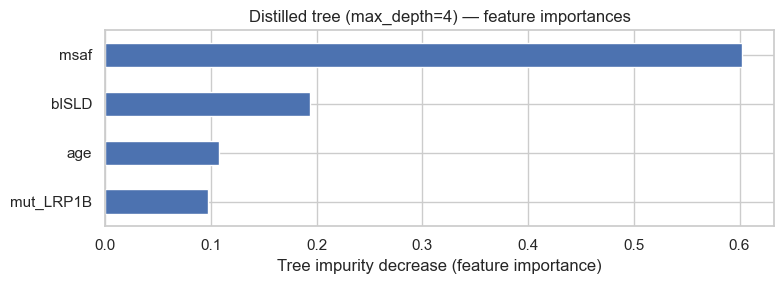

In [11]:
imp = pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=False)
nonzero = imp[imp > 0]

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(nonzero))))
nonzero[::-1].plot.barh(ax=ax, color="C0")
ax.set_xlabel("Tree impurity decrease (feature importance)")
ax.set_title("Distilled tree (max_depth=4) — feature importances")
plt.tight_layout()